# OpenBind-HIPPO

- **Target: A71EV2A**
- **Cycle: 01**

## Imports

In [1]:
%load_ext autoreload
%autoreload 2
import hippo
import mrich
from mrich import print
from pathlib import Path
from os import environ
import shutil
import molparse as mp
import pandas as pd
import plotly.express as px
from mocassin.mocassin import calculate_mocassin_tversky

## Config

In [2]:
target_name = "A71EV2A"
target_dir = Path(environ["BULK"]) / "TARGETS" / target_name
cycle_name = "cycle_01"
cycle_dir = Path(cycle_name)
aligned_dir = target_dir / "aligned_files"

## Animal

In [3]:
animal = hippo.HIPPO(target_name, target_dir / f"{target_name}.sqlite")

 Creating HIPPO animal

name = A71EV2A

db_path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

DEBUG: hippo.Database.__init__()

DEBUG: Database.path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

DEBUG: hippo.Database.connect()

DEBUG: sqlite3.version='2.6.0'

 Success  Database connected @ /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite!

 Success  Initialised animal HIPPO("A71EV2A")!

## Load Score CSV

In [28]:
score_df = pd.read_csv(cycle_dir / "gnina" / "openbind_a71ev21_c1_scaffold_products_score.csv")
score_df.head()

,name,gnina_score,gnina_score_min,smina_score_min,min_rmsd,Unnamed: 5
0,P810,5.630,5.567,-7.526,0.553,NaN
1,P944,4.463,4.347,-5.610,0.652,NaN
2,P1410,3.491,3.274,-2.857,2.045,NaN
3,P1411,3.509,3.495,-2.406,1.582,NaN
4,P2537,4.326,3.984,-4.300,0.648,NaN


In [29]:
c = animal.db.execute("""
SELECT compound_id, pose_id, pose_reference
FROM pose
INNER JOIN compound
ON pose_compound = compound_id
""")

lookup = {}
for cid, pid, ref in c:
    lookup.setdefault(cid, {})
    lookup[cid].setdefault(ref, set())
    lookup[cid][ref].add(pid)

In [30]:
def match_name(name):
    if name.startswith("P"):
        pose = getattr(animal, name)
        comp = pose.compound
    else:
        pose = animal.poses[name]
        comp = pose.compound
    
        if not name.startswith(f"C{comp.id}"):
            mrich.error(name, comp.id, pose.id)

        ref = int(name.split("-P")[-1])

        return list(lookup[comp.id][ref])[0], comp.id
    
    return pose.id, comp.id        

In [31]:
for i,row in mrich.track(score_df.iterrows(), total=len(score_df)):
    pose_id, comp_id = match_name(row["name"])
    score_df.loc[i, "comp_id"] = comp_id
    score_df.loc[i, "pose_id"] = pose_id
score_df = score_df.reset_index()
score_df["comp_id"] = score_df["comp_id"].astype(int)
score_df["pose_id"] = score_df["pose_id"].astype(int)
score_df = score_df.set_index(["comp_id", "pose_id"])

Output()

In [32]:
score_df.head()

index   name  gnina_score  gnina_score_min  smina_score_min  \
comp_id pose_id                                                                
45982   810          0   P810        5.630            5.567           -7.526   
33321   944          1   P944        4.463            4.347           -5.610   
47239   1410         2  P1410        3.491            3.274           -2.857   
        1411         3  P1411        3.509            3.495           -2.406   
97401   2537         4  P2537        4.326            3.984           -4.300   

                 min_rmsd  Unnamed: 5  
comp_id pose_id                        
45982   810         0.553         NaN  
33321   944         0.652         NaN  
47239   1410        2.045         NaN  
        1411        1.582         NaN  
97401   2537        0.648         NaN

In [133]:
for (comp_id, pose_id),row in mrich.track(score_df.iterrows(), total=len(score_df)):
    pose = animal.poses[pose_id]
    metadata = dict(pose.metadata)
    metadata["GNINA pK"] = row["gnina_score"]
    pose.metadata.update(metadata)

Output()

## Load poses

In [45]:
animal.db.backup()

 DISK  Writing /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A_1BCJ9UG.sqlite...

Output()

DEBUG: Copied 10000 of 581153 pages...

DEBUG: Copied 20000 of 581153 pages...

DEBUG: Copied 30000 of 581153 pages...

...

DEBUG: Copied 550000 of 581153 pages...

DEBUG: Copied 560000 of 581153 pages...

DEBUG: Copied 570000 of 581153 pages...

DEBUG: Copied 580000 of 581153 pages...

DEBUG: Copied 581153 of 581153 pages...

In [62]:
animal.load_sdf(
    target="A71EV2A",
    path="cycle_01/gnina/openbind_a71ev2a_c1_scaffold_products_minimized.sdf",
    pose_tags=["GNINA minimised"],
    name_col=None,
    # reference_col=None,
    # inspiration_col=None,
    energy_score_col="minimizedAffinity",
    distance_score_col="minimizedRMSD",
)

DEBUG: path=PosixPath('cycle_01/gnina/openbind_a71ev2a_c1_scaffold_products_minimized.sdf')

 Warning  Skipping existing target with name='A71EV2A'!

SDF entries (pre-filter) = 1518

SDF entries (post-filter) = 1518

DEBUG: #smiles 1071

...

DEBUG: Registering poses...

DEBUG: Adding tags...

Tagged {P × 1518} w/ "GNINA minimised"

 Warning  0 new compounds from cycle_01/gnina/openbind_a71ev2a_c1_scaffold_products_minimized.sdf!

 Warning  0 new poses from cycle_01/gnina/openbind_a71ev2a_c1_scaffold_products_minimized.sdf!

In [63]:
animal.poses(tag="GNINA minimised").interactive()

Output()

## Plots

In [40]:
score_df["distance_score"] = [animal.poses[pose_id].distance_score for (comp_id, pose_id),_ in score_df.iterrows()]

In [43]:
score_df["energy_score"] = [animal.poses[pose_id].energy_score for (comp_id, pose_id),_ in score_df.iterrows()]

In [38]:
score_df["gnina_score_diff"] = score_df["gnina_score_min"] - score_df["gnina_score"]

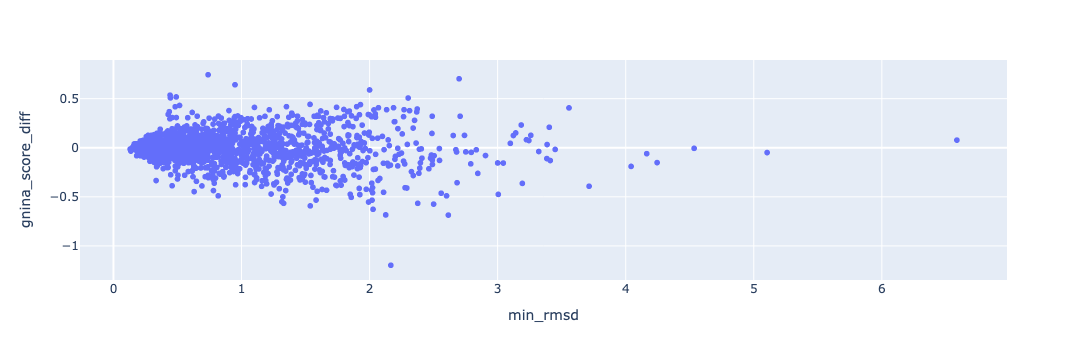

In [39]:
px.scatter(score_df, x="min_rmsd", y="gnina_score_diff")

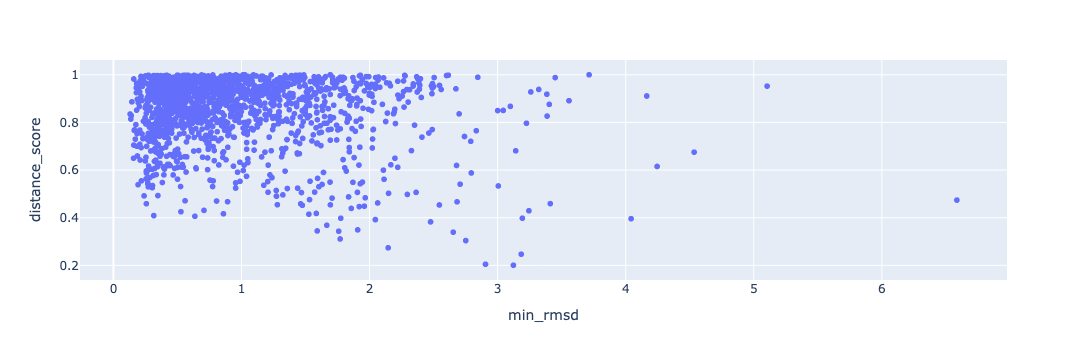

In [42]:
px.scatter(score_df, x="min_rmsd", y="distance_score")

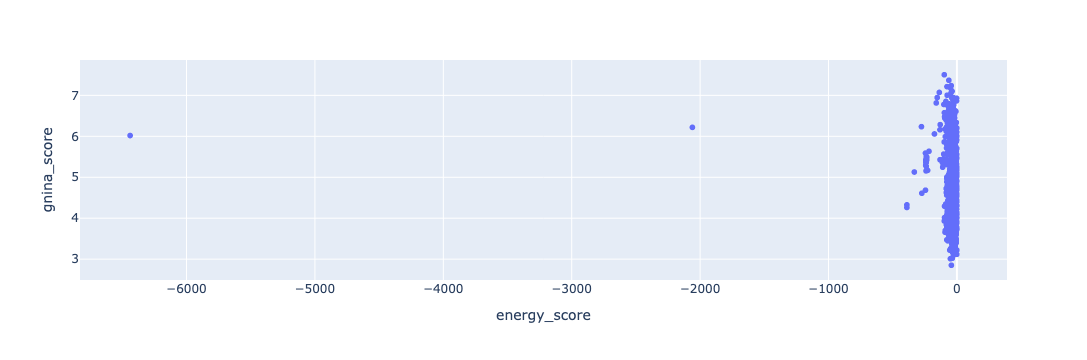

In [44]:
px.scatter(score_df, x="energy_score", y="gnina_score")

## Compare poses

In [33]:
mp = animal.poses(tag="GNINA minimised")[1]
print(mp)
mp.draw()
score_df[score_df.index.get_level_values(0) == mp.compound_id]

C33321->P496283: "BCNBKEWHVXULKZ-UHFFFAOYSA-N"

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

index         name  gnina_score  gnina_score_min  \
comp_id pose_id                                                     
33321   944          1         P944        4.463            4.347   
        944        376  C33321-P170        4.463            4.347   

                 smina_score_min  min_rmsd  Unnamed: 5  
comp_id pose_id                                         
33321   944                -5.61     0.652         NaN  
        944                -5.61     0.652         NaN

In [41]:
for pose in animal.poses(tag="GNINA minimised"):
    print(pose)
    pose_ids = list(score_df[score_df.index.get_level_values(0) == pose.compound_id].index.get_level_values(1))
    pset = animal.poses[pose_ids]
    for p in pset:
        print(p.id, p.reference.id, p.inspirations.ids)
    break

C45982->P496282: "GKCNSIZRNSZJLZ-UHFFFAOYSA-N"

810 611
[200, 611]

123616 611
[200, 611]

140667 197
[197, 200]

155452 173
[173, 200]

237296 244
[124, 244]

245992 401
[200, 401]

In [46]:
mdf = PandasTools.LoadSDF("cycle_01/gnina/openbind_a71ev2a_c1_scaffold_products_minimized_orig.sdf")

[12:19:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:19:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:19:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:19:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:19:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:19:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:19:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:19:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:19:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

In [50]:
# from rdkit.Chem import PandasTools
sdf = PandasTools.LoadSDF("cycle_01/bulkdock/openbind_a71ev2a_c1_scaffold_products.sdf")
sdf = sdf.set_index("ID")

In [57]:
for i,row in mdf.iterrows():
    try:
        match = sdf.loc[row["ID"]]
    except KeyError:
        mrich.error(i)
        continue
    mdf.loc[i, "ref_mols"] = match["ref_mols"]
    mdf.loc[i, "ref_pdb"] = match["ref_pdb"]

 ERROR  2!

 ERROR  53!

 ERROR  67!

 ERROR  70!

 ERROR  71!

...

 ERROR  1469!

 ERROR  1473!

 ERROR  1495!

 ERROR  1504!

 ERROR  1516!

In [61]:
PandasTools.WriteSDF(mdf, "cycle_01/gnina/openbind_a71ev2a_c1_scaffold_products_minimized.sdf", properties=mdf.columns)

In [88]:
score_df[score_df.index.get_level_values(1) == 810]

,,name,gnina_score,gnina_score_min,smina_score_min,min_rmsd,Unnamed: 5,gnina_score_diff,distance_score,energy_score
comp_id,pose_id,,,,,,,,,
99664,810,P810,5.63,5.567,-7.526,0.553,NaN,-0.063,0.997827,-61.135087


In [135]:
score_df[score_df["name"] == "C33321-P170"]

,,index,name,gnina_score,gnina_score_min,smina_score_min,min_rmsd,Unnamed: 5
comp_id,pose_id,,,,,,,
62872,123821,376,C33321-P170,4.463,4.347,-5.61,0.652,NaN


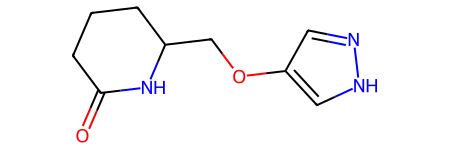

In [78]:
mp.compound.draw()

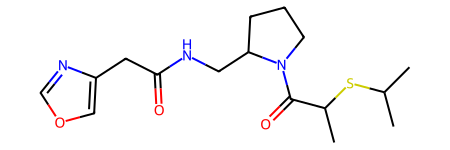

In [64]:
animal.P810.compound.draw()

In [65]:
mp.compound.smiles

'O=S(=O)(C1CCCN(c2ncco2)C1)N1CCc2ccccc21'

In [69]:
animal.db.query_similarity('O=S(=O)(C1CCCN(c2ncco2)C1)N1CCc2ccccc21', 0.9).ids

[45982]

In [95]:
pset = animal.C33321.poses
print(animal.db.get_pose_tag_dict(pset))
pset

{
    496283: {'GNINA minimised'},
    496658: {'GNINA minimised'},
    4078: {'openbind_a71ev2a_c1_knitwork_pure', 'fragmenstein_placed'},
    137083: {'openbind_a71ev2a_c1_knitwork_pure', 'fragmenstein_placed'},
    137084: {'openbind_a71ev2a_c1_knitwork_pure', 'fragmenstein_placed'},
    348282: {'openbind_a71ev2a_c1_knitwork_impure', 'fragmenstein_placed'},
    348825: {'openbind_a71ev2a_c1_knitwork_impure', 'fragmenstein_placed'},
    348826: {'openbind_a71ev2a_c1_knitwork_impure', 'fragmenstein_placed'},
    424915: {'openbind_a71ev2a_c1_knitwork_impure', 'fragmenstein_placed'}
}

C33321's poses: {P × 9}

In [100]:
score_df[(score_df.index.get_level_values(0) > 33300) & (score_df.index.get_level_values(0) < 33452)]

,,name,gnina_score,gnina_score_min,smina_score_min,min_rmsd,Unnamed: 5,gnina_score_diff,distance_score,energy_score
comp_id,pose_id,,,,,,,,,
33363,451456,C7529-P441,3.833,3.817,-4.96,0.779,NaN,-0.016,0.904046,-18.740754


In [128]:
match_name("C33321-P170")

 ERROR  C33321-P170 62872 123821!

{123821}

(123821, 62872)

In [102]:
animal.poses["C33321-P170"]

C62872->P123821: "C33321-P170"

In [105]:
animal.P123821.summary()

 P123821: C33321-P170

inchikey = QYUCNRDAJOKRPK-UHFFFAOYSA-N

alias = C33321-P170

smiles = O=C1CCC[C@H](COc2cnc2)N1

compound = C62872 "QYUCNRDAJOKRPK-UHFFFAOYSA-N"

...

energy_score = -33.561940560608434

inspiration_score = None

inspirations =
['A0556a', 'A3579a']

num_atoms_added = -9

metadata = {'Energy': 15.240540927600831, 'scratch_subdir': 
'/opt/xchem-fragalysis-2/maxwin/BulkDock/SCRATCH/512156/C33321-P170', 'fragmenstein_runtime': 4.230366468429565, 
'fragmenstein_outcome': 'acceptable', 'fragmenstein_mode': 'expansion', 'fragmenstein_error': '', 'exports': 
['/opt/xchem-fragalysis-2/maxwin/BulkDock/OUTPUTS/openbind_a71ev2a_c1_knitwork_pure_165VWF8.sdf', 
'/opt/xchem-fragalysis-2/maxwin/BulkDock/OUTPUTS/openbind_a71ev2a_c1_knitwork_pure_1B07PTU.sdf', 
'/opt/xchem-fragalysis-2/maxwin/BulkDock/OUTPUTS/openbind_a71ev2a_c1_knitwork_pure_1B07UWE.sdf', 
'/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/openbind_a71ev2a_c1_scaffold_products.sdf', 
'/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_01/bulkdock/openbind_a71ev2a_c1_scaffold_products.sdf'
, '/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_01/bulkdock/openbind_a71ev2a_c1_scaffolds.sdf'], 
'GNINA pK': 4.463}

## Cleanup messy poses

In [117]:
c = animal.db.execute("""
SELECT pose_id FROM pose
WHERE pose_alias LIKE 'C%-P%'
""")

pset = animal.poses[[i for i, in c]]
pset

{P × 372929}

In [121]:
mol_block = """
     RDKit          3D

 27 28  0  0  0  0  0  0  0  0999 V2000
    7.0381   10.3908   25.8630 O   0  0  0  0  0  0  0  0  0  0  0  0
    7.8008   10.8530   25.0216 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.5970    9.9524   24.1295 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.7349   10.5535   23.3501 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.9206   12.0573   23.4739 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.6138   12.7964   23.7398 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.8591   14.3007   23.9581 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.1050   14.9406   22.7137 O   0  0  0  0  0  0  0  0  0  0  0  0
   10.3906   15.1247   22.3568 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.8366   15.3382   21.0406 C   0  0  0  0  0  0  0  0  0  0  0  0
   12.1571   15.5066   20.9876 N   0  0  0  0  0  0  0  0  0  0  0  0
   12.5415   15.4569   22.2676 N   0  0  0  0  0  0  0  0  0  0  0  0
   11.5188   15.1971   23.1397 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.9427   12.1974   24.8779 N   0  0  0  0  0  0  0  0  0  0  0  0
    7.9218    9.4633   23.4420 H   0  0  0  0  0  0  0  0  0  0  0  0
    8.9784    9.1425   24.7403 H   0  0  0  0  0  0  0  0  0  0  0  0
    9.6254   10.2836   22.2984 H   0  0  0  0  0  0  0  0  0  0  0  0
   10.6417   10.0311   23.6522 H   0  0  0  0  0  0  0  0  0  0  0  0
   10.6217   12.2750   24.2860 H   0  0  0  0  0  0  0  0  0  0  0  0
   10.3981   12.4210   22.5600 H   0  0  0  0  0  0  0  0  0  0  0  0
    7.9505   12.6676   22.8781 H   0  0  0  0  0  0  0  0  0  0  0  0
    7.9378   14.7527   24.3466 H   0  0  0  0  0  0  0  0  0  0  0  0
    9.6190   14.4920   24.7244 H   0  0  0  0  0  0  0  0  0  0  0  0
   10.2614   15.3763   20.1242 H   0  0  0  0  0  0  0  0  0  0  0  0
   13.5263   15.6091   22.4586 H   0  0  0  0  0  0  0  0  0  0  0  0
   11.6995   15.1356   24.1998 H   0  0  0  0  0  0  0  0  0  0  0  0
    7.2173   12.7208   25.3586 H   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  2  0
  2  3  1  0
  3  4  1  0
  4  5  1  0
  5  6  1  0
  6  7  1  0
  7  8  1  0
  8  9  1  0
  9 10  1  0
 10 11  2  0
 11 12  1  0
 12 13  1  0
  6 14  1  0
 14  2  1  0
 13  9  2  0
  3 15  1  0
  3 16  1  0
  4 17  1  0
  4 18  1  0
  5 19  1  0
  5 20  1  0
  6 21  1  0
  7 22  1  0
  7 23  1  0
 10 24  1  0
 12 25  1  0
 13 26  1  0
 14 27  1  0
M  END
"""

In [122]:
from rdkit import Chem

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

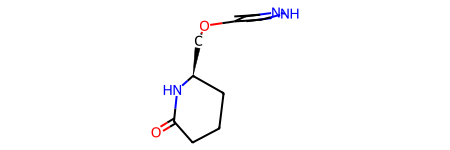

In [123]:
Chem.MolFromMolBlock(mol_block)

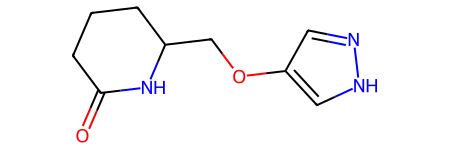

In [125]:
animal.C33321.draw()

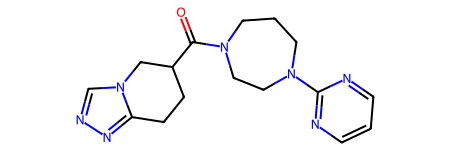

In [136]:
animal.C62872.draw()

## FIX pose_compound FROM pose_mol

In [137]:
animal.P123821.smiles

'O=C1CCC[C@H](COc2cn[nH]c2)N1'

In [138]:
from hippo.tools import sanitise_smiles

In [139]:
sanitise_smiles("O=C1CCC[C@H](COc2cn[nH]c2)N1")

'O=C1CCCC(COc2cn[nH]c2)N1'

In [140]:
animal.compounds(smiles="O=C1CCC[C@H](COc2cn[nH]c2)N1")

C33321 "BCNBKEWHVXULKZ-UHFFFAOYSA-N"

In [16]:
lookup = animal.db.get_compound_id_smiles_dict()
lookup = {v:k for k,v in lookup.items()}

In [20]:
c = animal.db.execute(
# """
# SELECT pose_id, pose_compound, pose_smiles, mol_to_smiles(mol_from_binary_mol(pose_mol)) 
# FROM pose 
# WHERE pose_id IN (646,647)
# """

"""
SELECT pose_id, pose_compound, pose_smiles 
FROM pose 
"""
)
records = c.fetchall()
len(records)

497799

In [23]:
fixes = []

for pid, c1, s1 in mrich.track(records):
    # print(pid, c1, s1)

    # if s1 != s2:
    #     mrich.error(pid, "SMILES MISMATCH")

    try:
        flat = sanitise_smiles(s1)
    except:
        mrich.error("Sanitisation error", pid, s1)
        continue

    c2 = lookup.get(flat)

    if not c2:
        continue

    if c1 != c2:
        # mrich.error(pid, "COMPOUND MISMATCH")
        fixes.append((pid, c2, s2))

Output()

[12:04:32] SMILES Parse Error: syntax error while parsing: CCC[SOH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c1

[12:04:32] SMILES Parse Error: check for mistakes around position 6:

[12:04:32] CCC[SOH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c

[12:04:32] ~~~~~^

...

[12:06:44] SMILES Parse Error: check for mistakes around position 22:

[12:06:44] [CH](c1ccncc1)N(C)[STB2](=O)(=O)c1cccc2c1

[12:06:44] ~~~~~~~~~~~~~~~~~~~~^

[12:06:44] SMILES Parse Error: Failed parsing SMILES 'C[CH](c1ccncc1)N(C)[STB2](=O)(=O)c1cccc2c1CCN2' for input: 
'C[CH](c1ccncc1)N(C)[STB2](=O)(=O)c1cccc2c1CCN2'

 ERROR  Sanitisation error 493398 C[C@H](c1ccncc1)N(C)[S@TB2](=O)(=O)c1cccc2c1CCN2!

In [24]:
len(fixes)

394415

In [25]:
fixes[0]

(646, 9341, 'CCc1cnc(CC(=O)N[C@H](C)CNC(=O)c2ccccn2)[nH]1')

In [27]:
sql = """
UPDATE pose
SET pose_compound = ?2
WHERE pose_id = ?1
"""

animal.db.executemany(sql, [(a,b) for a,b,c in fixes])
animal.db.commit()

646

45697

C[C@H](CNC(=O)c1ccccn1)NC(=O)Cc1ncc1

CC(C)(C)Cn1cc(NC(=O)CCCN2CCCCC2)cn1

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

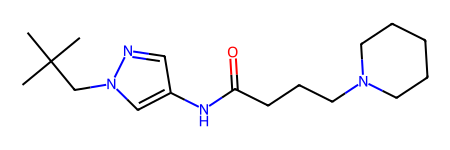

In [159]:
p = animal.P646

print(p.id)
print(p.compound_id)
print(p.smiles)
print(p.compound.smiles)
p.draw()
p.compound.draw()

In [11]:
import re
import numpy as np
from molparse.rdkit import mol_from_smiles
from rdkit.Chem.inchi import MolToInchiKey
from rdkit.Chem import MolFromSmiles, MolToSmiles, AddHs, RemoveHs
import mcol
from datetime import datetime
from string import ascii_uppercase

import mrich


def smiles_has_isotope(smiles, regex=True):
    """

    :param smiles:
    :param regex:  (Default value = True)

    """
    if regex:
        return re.search(r"([\[][0-9]+[A-Z]+\])", smiles)
    else:
        mol = MolFromSmiles(smiles)
        return any(atom.GetIsotope() for atom in mol.GetAtoms())

def sanitise_smiles(s, verbosity=False, sanitisation_failed="error", radical="error"):
    """

    :param s:
    :param verbosity:  (Default value = False)
    :param sanitisation_failed:  (Default value = 'error')
    :param radical:  (Default value = 'error')

    """

    assert isinstance(s, str), f"non-string smiles={s}"

    orig_smiles = s

    # if multiple molecules take the largest
    if "." in s:
        s = sorted(s.split("."), key=lambda x: len(x))[-1]

    # flatten the smiles
    stereo_smiles = s
    smiles = s.replace("@", "")
    smiles = smiles.replace("/", "")
    smiles = smiles.replace("\\", "")

    # remove isotopic stuff
    if smiles_has_isotope(smiles):
        mrich.warning(f"Isotope(s) in SMILES: {smiles}")
        smiles = remove_isotopes_from_smiles(smiles)

    # canonicalise
    mol = MolFromSmiles(smiles)
    if mol:
        smiles = MolToSmiles(mol, True)
    elif sanitisation_failed == "error":
        raise SanitisationError
    elif sanitisation_failed == "warning":
        mrich.warning(f"sanitisation failed for {smiles=}")

    # check radicals
    reconstruct = False
    for atom in mol.GetAtoms():
        if not atom.GetNumRadicalElectrons():
            continue

        if radical == "warning":
            mrich.warning(f"Radical atom in {smiles=}")
        elif radical == "error":
            raise SanitisationError(f"Radical atom in {smiles=}")
        elif radical == "remove":
            mrich.warning(f"Removed radical atom")
            atom.SetNumRadicalElectrons(0)
            smiles = MolToSmiles(mol, True)
            reconstruct = True
            # atom.SetFormalCharge(0)
        else:
            raise NotImplementedError(f"Unknown option {radical=}")

    if reconstruct:
        mol = AddHs(mol)
        mol = RemoveHs(mol, implicitOnly=True)
        smiles = MolToSmiles(mol, True)
        mrich.warning(f"New {smiles=}")

    if verbosity:

        if smiles != orig_smiles:

            annotated_smiles_str = orig_smiles.replace(
                ".", f"{mcol.error}{mcol.underline}.{mcol.clear}{mcol.warning}"
            )
            annotated_smiles_str = annotated_smiles_str.replace(
                "@", f"{mcol.error}{mcol.underline}@{mcol.clear}{mcol.warning}"
            )

            mrich.warning(f"SMILES was changed: {annotated_smiles_str} --> {smiles}")

    return smiles

In [22]:
sanitise_smiles("CCC[S@OH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c1")

[12:03:25] SMILES Parse Error: syntax error while parsing: CCC[SOH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c1
[12:03:25] SMILES Parse Error: check for mistakes around position 6:
[12:03:25] CCC[SOH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c
[12:03:25] ~~~~~^
[12:03:25] SMILES Parse Error: Failed parsing SMILES 'CCC[SOH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c1' for input: 'CCC[SOH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c1'


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 sanitise_smiles("CCC[S@OH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c1")                               │
│   2                                                                                              │
│                                                                                                  │
│ ╭─────────────────────────────────────────── locals ───────────────────────────────────────────╮ │
│ │           AddHs = <Boost.Python.function object at 0x55fe5137c600>                           │ │
│ │     aligned_dir = PosixPath('/opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/aligne… │ │
│ │          animal = HIPPO("A71EV2A")                                                           │ │
│ │ ascii_uppercase = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'                                               │ │
│ │               c = <sqlite3.Cursor object at 0x7f322d66ac40>                                  │ │
│ │              c1 = 225720                                                                     │ │
│ │              c2 = 174352                                                                     │ │
│ │       cycle_dir = PosixPath('cycle_01')                                                      │ │
│ │      cycle_name = 'cycle_01'                                                                 │ │
│ │         environ = environ({                                                                  │ │
│ │                   │   'HYDRA_LAUNCHER_EXTRA_ARGS': '--external-launcher',                    │ │
│ │                   │   'PRECURSOR': '/opt/xchem-fragalysis-2/maxwin/2A_Precursor_FFF',        │ │
│ │                   │   'MAMBA_ALWAYS_YES': 'yes',                                             │ │
│ │                   │   'CONDA_SHLVL': '1',                                                    │ │
│ │                   │   'LD_LIBRARY_PATH':                                                     │ │
│ │                   '/usr/local/cuda/compat:/opt/xchem-fragalysis-2/maxwin/conda/lib:/dls_sw/… │ │
│ │                   │   'LS_COLORS':                                                           │ │
│ │                   'rs=0:di=38;5;33:ln=38;5;51:mh=00:pi=40;38;5;11:so=38;5;13:do=38;5;5:bd=4… │ │
│ │                   │   'CONDA_EXE': '/opt/xchem-fragalysis-2/maxwin/conda/bin/conda',         │ │
│ │                   │   'SLURM_NODEID': '0',                                                   │ │
│ │                   │   'SLURM_TASK_PID': '157145',                                            │ │
│ │                   │   'SSH_CONNECTION': '172.23.162.11 43788 172.23.176.6 22',               │ │
│ │                   │   ... +131                                                               │ │
│ │                   })                                                                         │ │
│ │            exit = <IPython.core.autocall.ZMQExitAutocall object at 0x7f3382ecf920>           │ │
│ │           fixes = [                                                                          │ │
│ │                   │   (646, 9341, 'CCc1cnc(CC(=O)N[C@H](C)CNC(=O)c2ccccn2)[nH]1'),           │ │
│ │                   │   (647, 9342, 'CCc1cnc(CC(=O)N[C@H](C)CNC(=O)c2ccccn2)[nH]1'),           │ │
│ │                   │   (648, 9344, 'CCc1cnc(CC(=O)N[C@H](C)CNC(=O)c2ccccn2)[nH]1'),           │ │
│ │                   │   (649, 68567, 'CCc1cnc(CC(=O)N[C@H](C)CNC(=O)c2ccccn2)[nH]1'),          │ │
│ │                   │   (650, 61147, 'CCc1cnc(CC(=O)N[C@H](C)CNC(=O)c2ccccn2)[nH]1'),          │ │
│ │                   │   (652, 68574, 'CCc1cnc(CC(=O)N[C@H](C)CNC(=O)c2ccccn2)[nH]1'),          │ │
│ │                   │   (653, 68575, 'CCc1cnc(CC(=O)N[C@H](

## Posecheck

In [66]:
%autoreload 2
from posecheck import PoseCheck

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│   1 get_ipython().run_line_magic('autoreload', '2')                                              │
│ ❱ 2 from posecheck import PoseCheck                                                              │
│   3                                                                                              │
│                                                                                                  │
│ ╭─────────────────────────────────────────── locals ───────────────────────────────────────────╮ │
│ │           AddHs = <Boost.Python.function object at 0x55fe5137c600>                           │ │
│ │     aligned_dir = PosixPath('/opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/aligne… │ │
│ │          animal = HIPPO("A71EV2A")                                                           │ │
│ │ ascii_uppercase = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'                                               │ │
│ │               c = <sqlite3.Cursor object at 0x7f322d66ac40>                                  │ │
│ │              c1 = 8142                                                                       │ │
│ │              c2 = 8142                                                                       │ │
│ │             cid = 8142                                                                       │ │
│ │         comp_id = 8142                                                                       │ │
│ │       cycle_dir = PosixPath('cycle_01')                                                      │ │
│ │      cycle_name = 'cycle_01'                                                                 │ │
│ │         environ = environ({                                                                  │ │
│ │                   │   'HYDRA_LAUNCHER_EXTRA_ARGS': '--external-launcher',                    │ │
│ │                   │   'PRECURSOR': '/opt/xchem-fragalysis-2/maxwin/2A_Precursor_FFF',        │ │
│ │                   │   'MAMBA_ALWAYS_YES': 'yes',                                             │ │
│ │                   │   'CONDA_SHLVL': '1',                                                    │ │
│ │                   │   'LD_LIBRARY_PATH':                                                     │ │
│ │                   '/usr/local/cuda/compat:/opt/xchem-fragalysis-2/maxwin/conda/lib:/dls_sw/… │ │
│ │                   │   'LS_COLORS':                                                           │ │
│ │                   'rs=0:di=38;5;33:ln=38;5;51:mh=00:pi=40;38;5;11:so=38;5;13:do=38;5;5:bd=4… │ │
│ │                   │   'CONDA_EXE': '/opt/xchem-fragalysis-2/maxwin/conda/bin/conda',         │ │
│ │                   │   'SLURM_NODEID': '0',                                                   │ │
│ │                   │   'SLURM_TASK_PID': '157145',                                            │ │
│ │                   │   'SSH_CONNECTION': '172.23.162.11 43788 172.23.176.6 22',               │ │
│ │                   │   ... +131                                                               │ │
│ │                   })                                                                         │ │
│ │            exit = <IPython.core.autocall.ZMQExitAutocall object at 0x7f3382ecf920>           │ │
│ │           fixes = [                                                                          │ │
│ │                   │   (646, 9341, 'CCc1cnc(CC(=O)N[C@H](C)CNC(=O)c2ccccn2)[nH]1'),           │ │
│ │                   │   (647, 9342, 'CCc1cnc(CC(=O)N[C@H](C)CNC(=O)c2ccccn2)[nH]1'),           │ │
│ │                   │   (648, 9344, 'CCc1cnc(CC(=O)N[C@H](C)CNC(=O)c2ccccn2)[nH]1'),           │ │
│ │                   │   (649, 68567, 'CCc1cnc(CC(=O)N[C@H](